##Project fashionMnist


In [65]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping

###Definition

In [66]:
(X_train,y_train),(X_test,y_test)=keras.datasets.fashion_mnist.load_data()

In [67]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


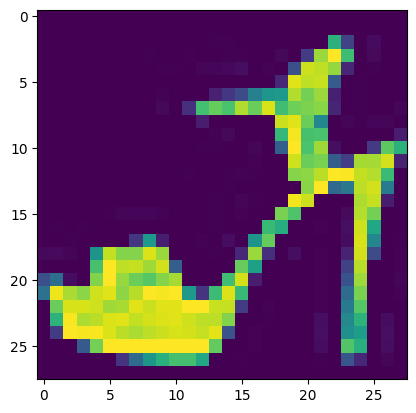

In [68]:
plt.imshow(X_train[9])

###Normalization

In [69]:
X_train, X_test = X_train/255, X_test/255

In [70]:
len(np.unique(y_train))

10

###Model

In [71]:
model=keras.Sequential(
    [
   keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(512, activation="selu"),
    keras.layers.Dense(256, activation="selu"),
    keras.layers.Dense(128, activation="selu"),
    keras.layers.Dense(256, activation="selu"),
    keras.layers.Dense(512, activation="selu"),
    keras.layers.Dense(10, activation="softmax")
    ]
 )

In [72]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 735,882 (2.81 MB)

 Trainable params: 735,882 (2.81 MB)

 Non-trainable params: 0 (0.00 B)

###compile

In [73]:
model.compile(
        optimizer="adam",
        loss='sparse_categorical_crossentropy',
        metrics=["accuracy"]
)

###EarlyStopping

In [74]:
eary_stop=EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )

###fit

In [75]:
history=model.fit(
        X_train,
        y_train,
        epochs =30,
        batch_size =100,
        validation_data =(X_test,y_test),
        callbacks =[eary_stop]
)

Epoch 1/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.8073 - loss: 0.5432 - val_accuracy: 0.8273 - val_loss: 0.5080
Epoch 2/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - accuracy: 0.8508 - loss: 0.4112 - val_accuracy: 0.8344 - val_loss: 0.4818
Epoch 3/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.8631 - loss: 0.3734 - val_accuracy: 0.8631 - val_loss: 0.3934
Epoch 4/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.8732 - loss: 0.3445 - val_accuracy: 0.8604 - val_loss: 0.3785
Epoch 5/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.8794 - loss: 0.3257 - val_accuracy: 0.8534 - val_loss: 0.4257
Epoch 6/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.8828 - loss: 0.3184 - val_accuracy: 0.8700 - val_loss: 0.3672
Epoch 7/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.8882 - loss: 0.3031 - val_accuracy: 0.8623 - val_loss: 0.3866
Epoch 8/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.8910 - loss: 0.2927 - 

###trainingPerformance

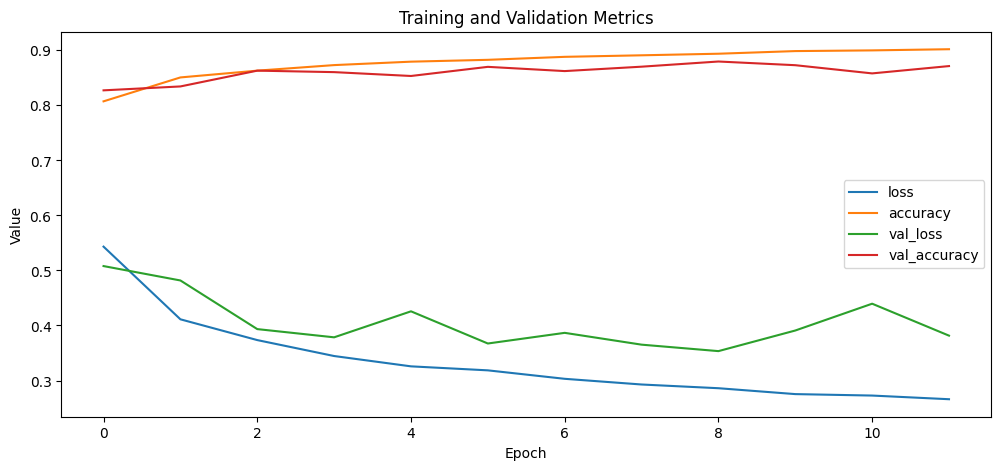

In [76]:

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(history.history['loss'], label='loss')
ax.plot(history.history['accuracy'], label='accuracy')
ax.plot(history.history['val_loss'], label='val_loss')
ax.plot(history.history['val_accuracy'], label='val_accuracy')

ax.set_xlabel('Epoch')
ax.set_ylabel('Value')
ax.set_title('Training and Validation Metrics')
ax.legend()
plt.show()

### testModel

In [77]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8797 - loss: 0.3534


[0.35340067744255066, 0.8797000050544739]

In [78]:
pred = model.predict(X_test[:20])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step


In [79]:
np.argmax(pred, axis=1)

array([9, 2, 1, 1, 6, 1, 4, 6, 5, 7, 4, 5, 8, 3, 4, 1, 2, 2, 8, 0])

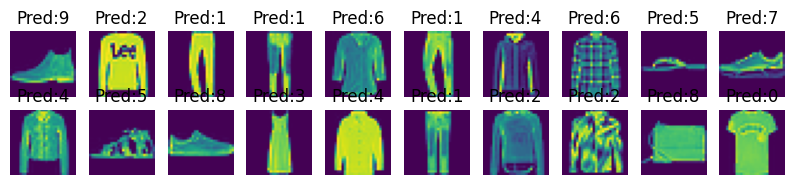

In [80]:

plt.figure(figsize=(10,10))

for i in range(20):
    plt.subplot(10,10,i+1)
    plt.imshow(X_test[0+i])
    plt.title(f"Pred:{np.argmax(pred[i])}")
    plt.axis("off")

plt.show()